In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
path = "/Users/debanjan_5402/Desktop/Conditional-GAN-based-Image-Restoration-from-Speckle-Interference-Pattern/dataset/train/img00072/img00072_speckle.pt"

data = torch.load(path)

In [3]:
def _plot(plots, titles):
    plt.figure(figsize=(18, 6), dpi=300)

    plt.subplot(131)
    plt.imshow(plots[0], cmap='gray')
    plt.axis("off")
    plt.colorbar(shrink=0.5)
    plt.title(titles[0])

    plt.subplot(132)
    plt.imshow(plots[1], cmap='gray')
    plt.axis("off")
    plt.colorbar(shrink=0.5)
    plt.title(titles[1])

    plt.subplot(133)
    plt.imshow(plots[2], cmap='gray')
    plt.axis("off")
    plt.colorbar(shrink=0.5)
    plt.title(titles[2])

    plt.tight_layout()
    plt.show()

### Raw Data

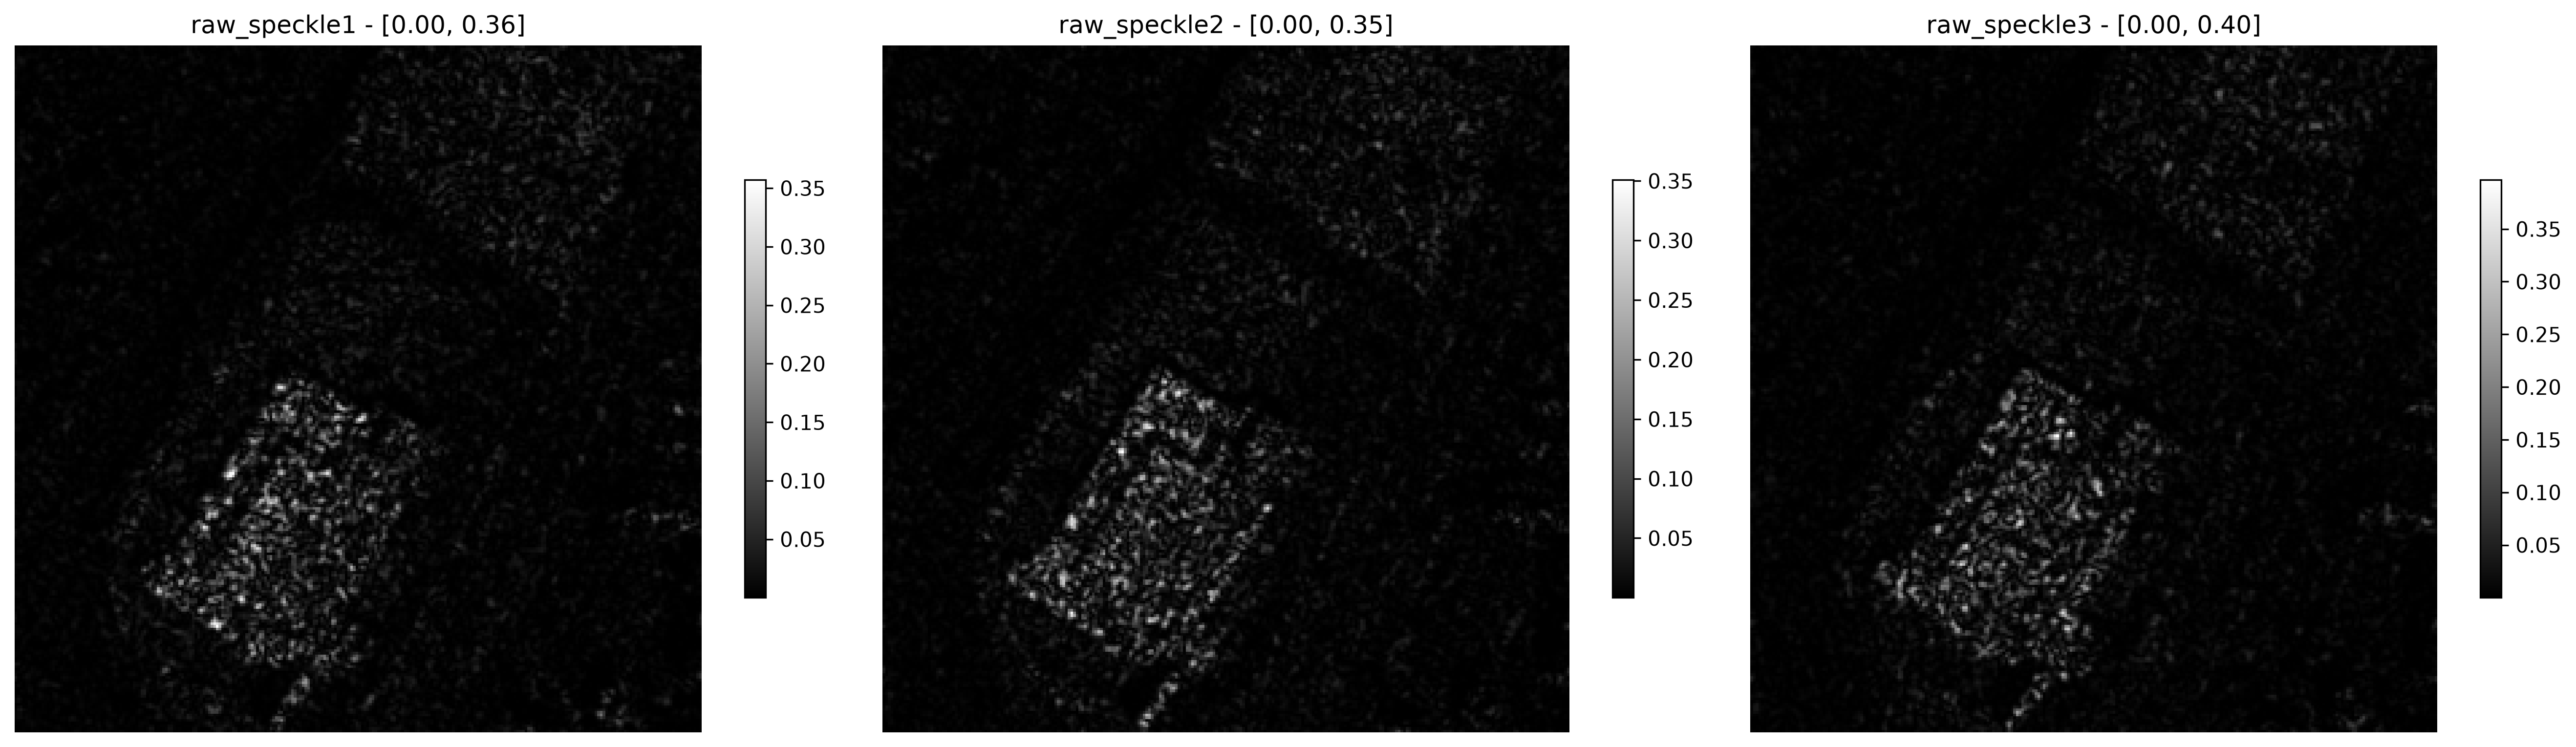

In [4]:
speckle1, speckle2, speckle3 = data[0], data[1], data[2]

_plot(plots=[speckle1, speckle2, speckle3], 
      titles=[f'raw_speckle1 - [{speckle1.min().item():0.2f}, {speckle1.max().item():0.2f}]',
              f'raw_speckle2 - [{speckle2.min().item():0.2f}, {speckle2.max().item():0.2f}]',
              f'raw_speckle3 - [{speckle3.min().item():0.2f}, {speckle3.max().item():0.2f}]'])

### Normalization to [0, 1]

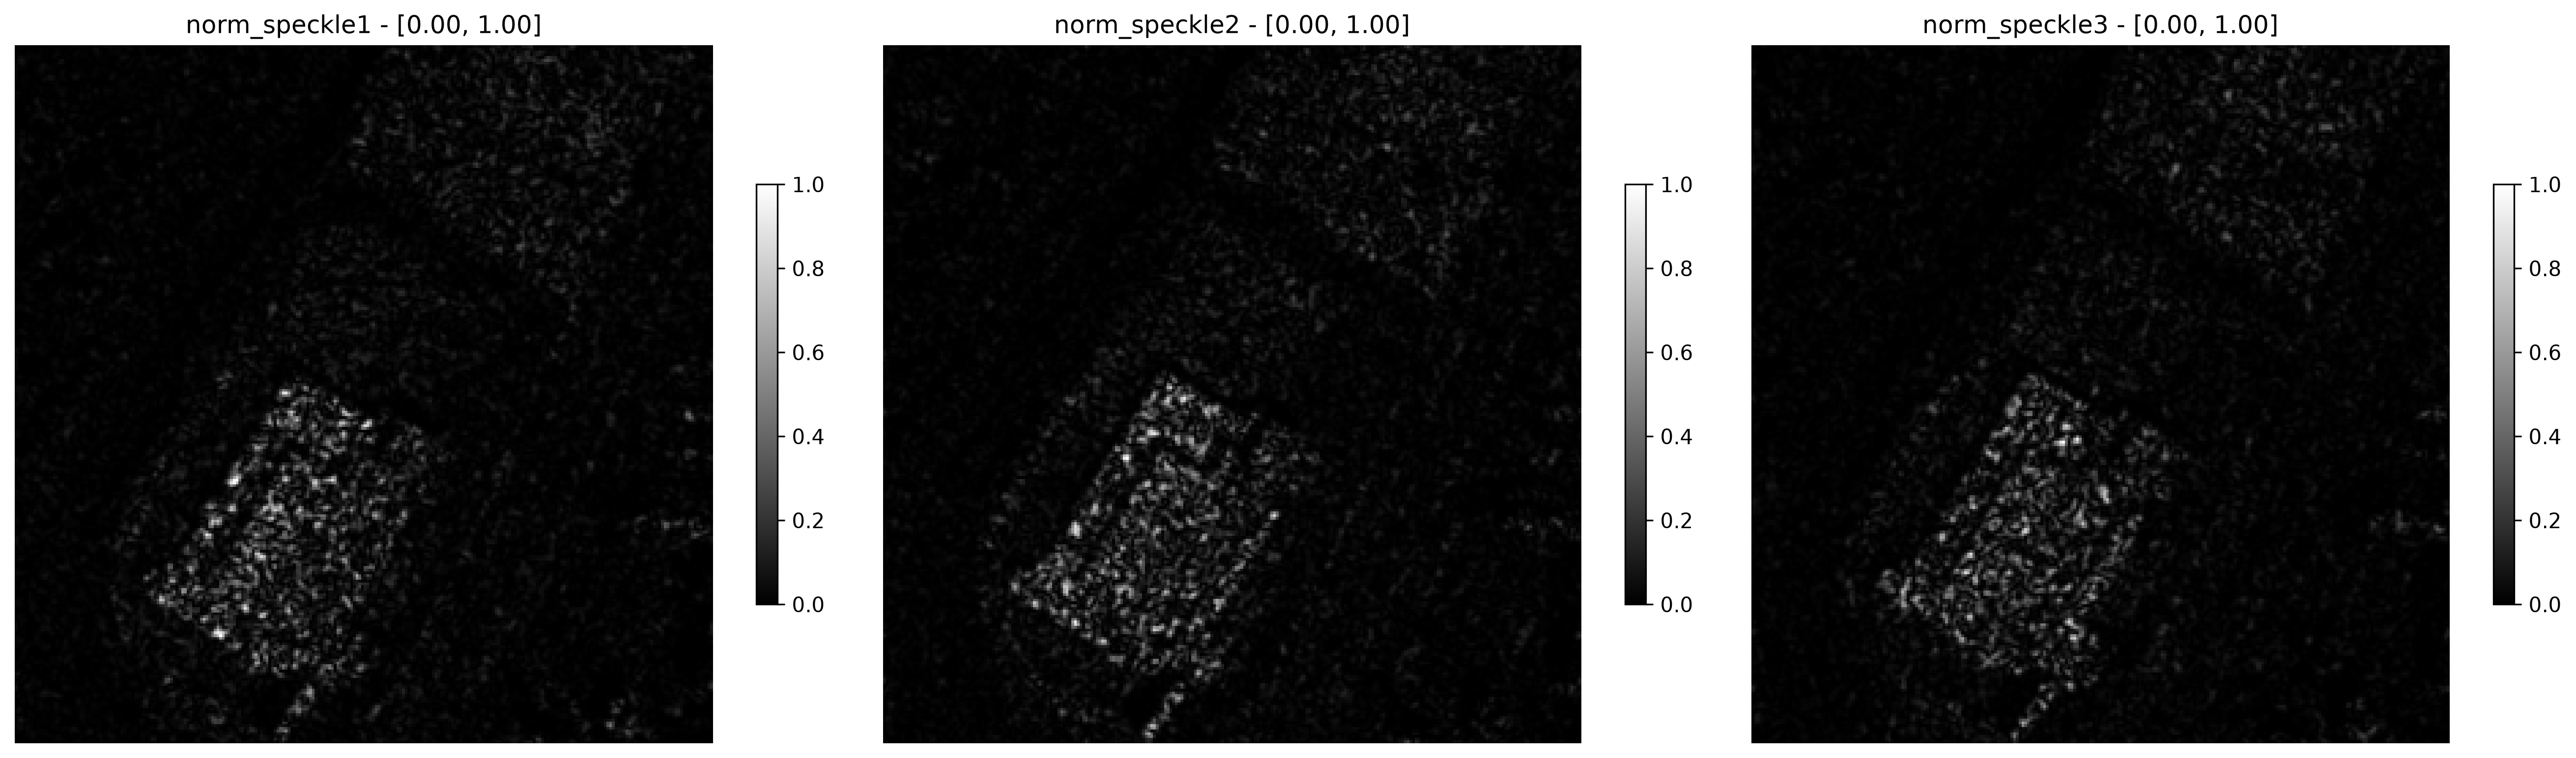

In [5]:
def _norm(x:torch.Tensor):
    return ((x - x.min())/(x.max() - x.min()))

speckle1 = _norm(speckle1)
speckle2 = _norm(speckle2)
speckle3 = _norm(speckle3)


_plot(plots=[speckle1, speckle2, speckle3], 
      titles=[f'norm_speckle1 - [{speckle1.min().item():0.2f}, {speckle1.max().item():0.2f}]',
              f'norm_speckle2 - [{speckle2.min().item():0.2f}, {speckle2.max().item():0.2f}]',
              f'norm_speckle3 - [{speckle3.min().item():0.2f}, {speckle3.max().item():0.2f}]'])

### Gamma Transformation

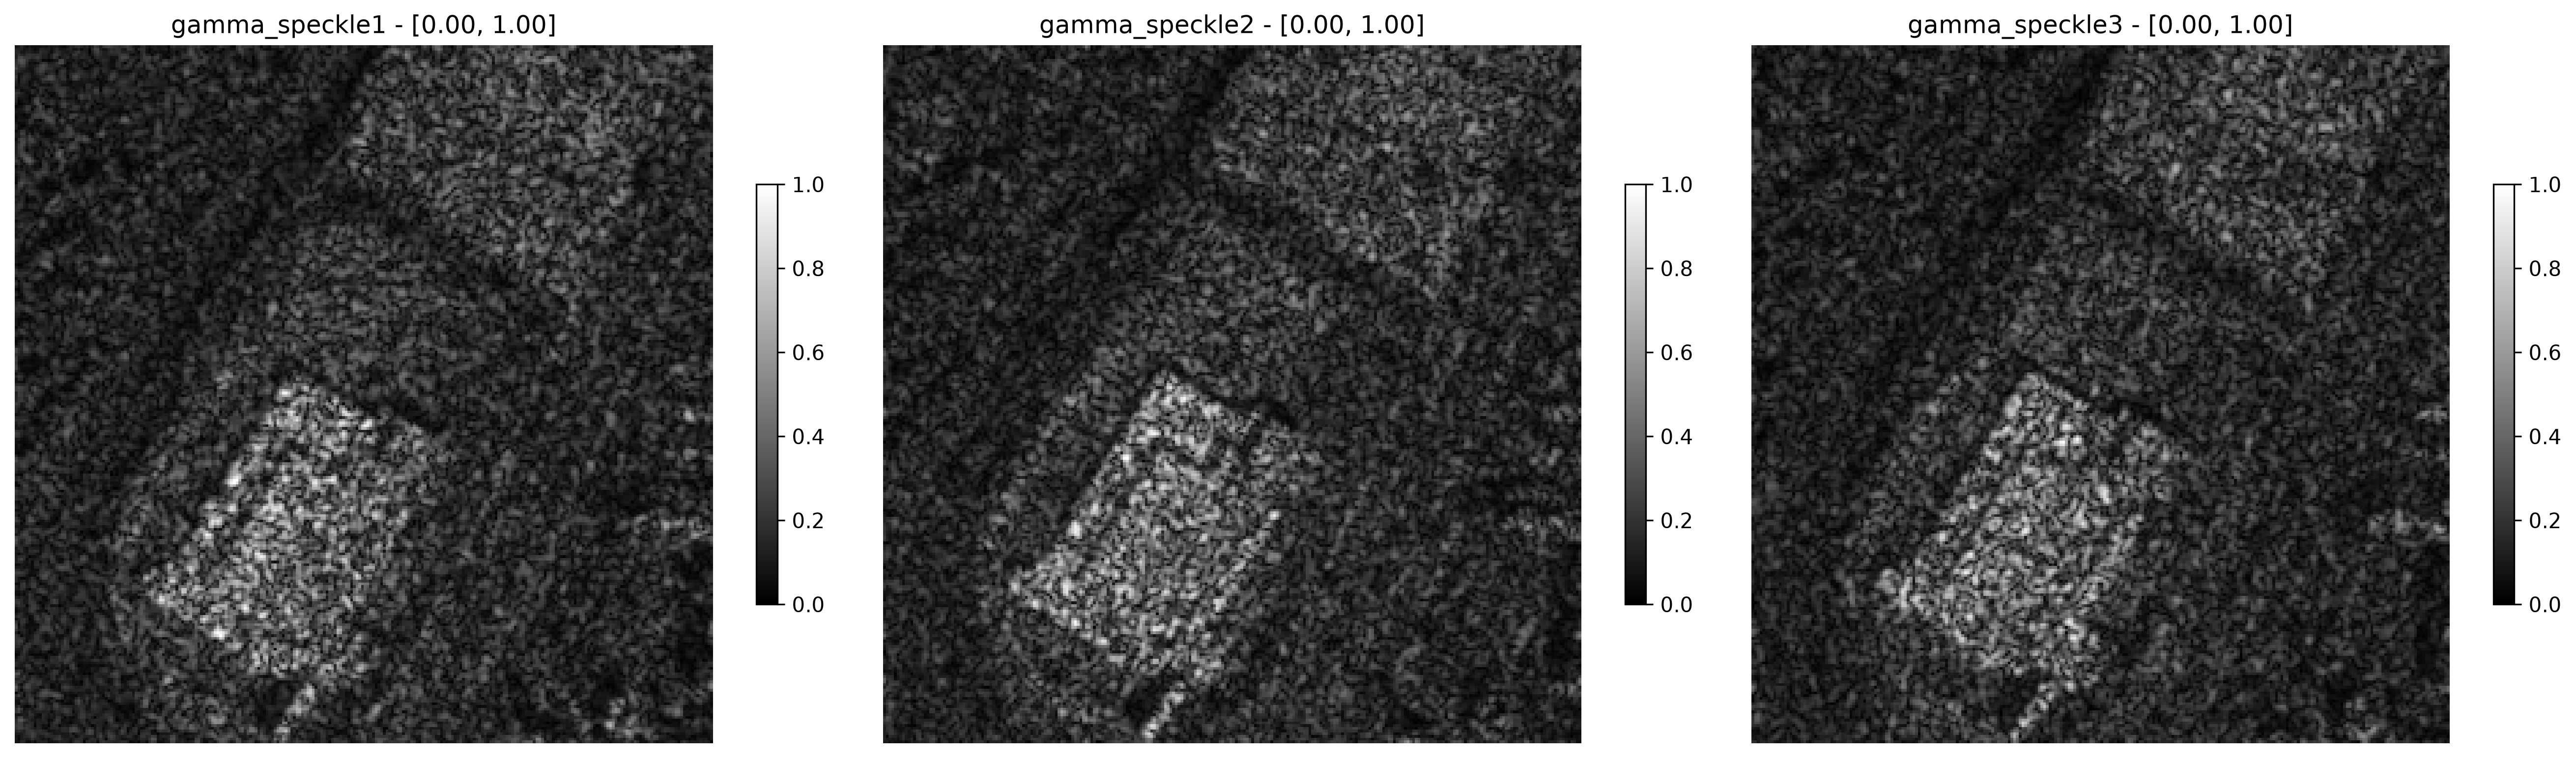

In [6]:
def _transform(x:torch.Tensor):
    x = x**0.42
    return x

speckle1 = _transform(speckle1)
speckle2 = _transform(speckle2)
speckle3 = _transform(speckle3)

_plot(plots=[speckle1, speckle2, speckle3], 
      titles=[f'gamma_speckle1 - [{speckle1.min().item():0.2f}, {speckle1.max().item():0.2f}]',
              f'gamma_speckle2 - [{speckle2.min().item():0.2f}, {speckle2.max().item():0.2f}]',
              f'gamma_speckle3 - [{speckle3.min().item():0.2f}, {speckle3.max().item():0.2f}]'])


### Normalize to [-1, 1]

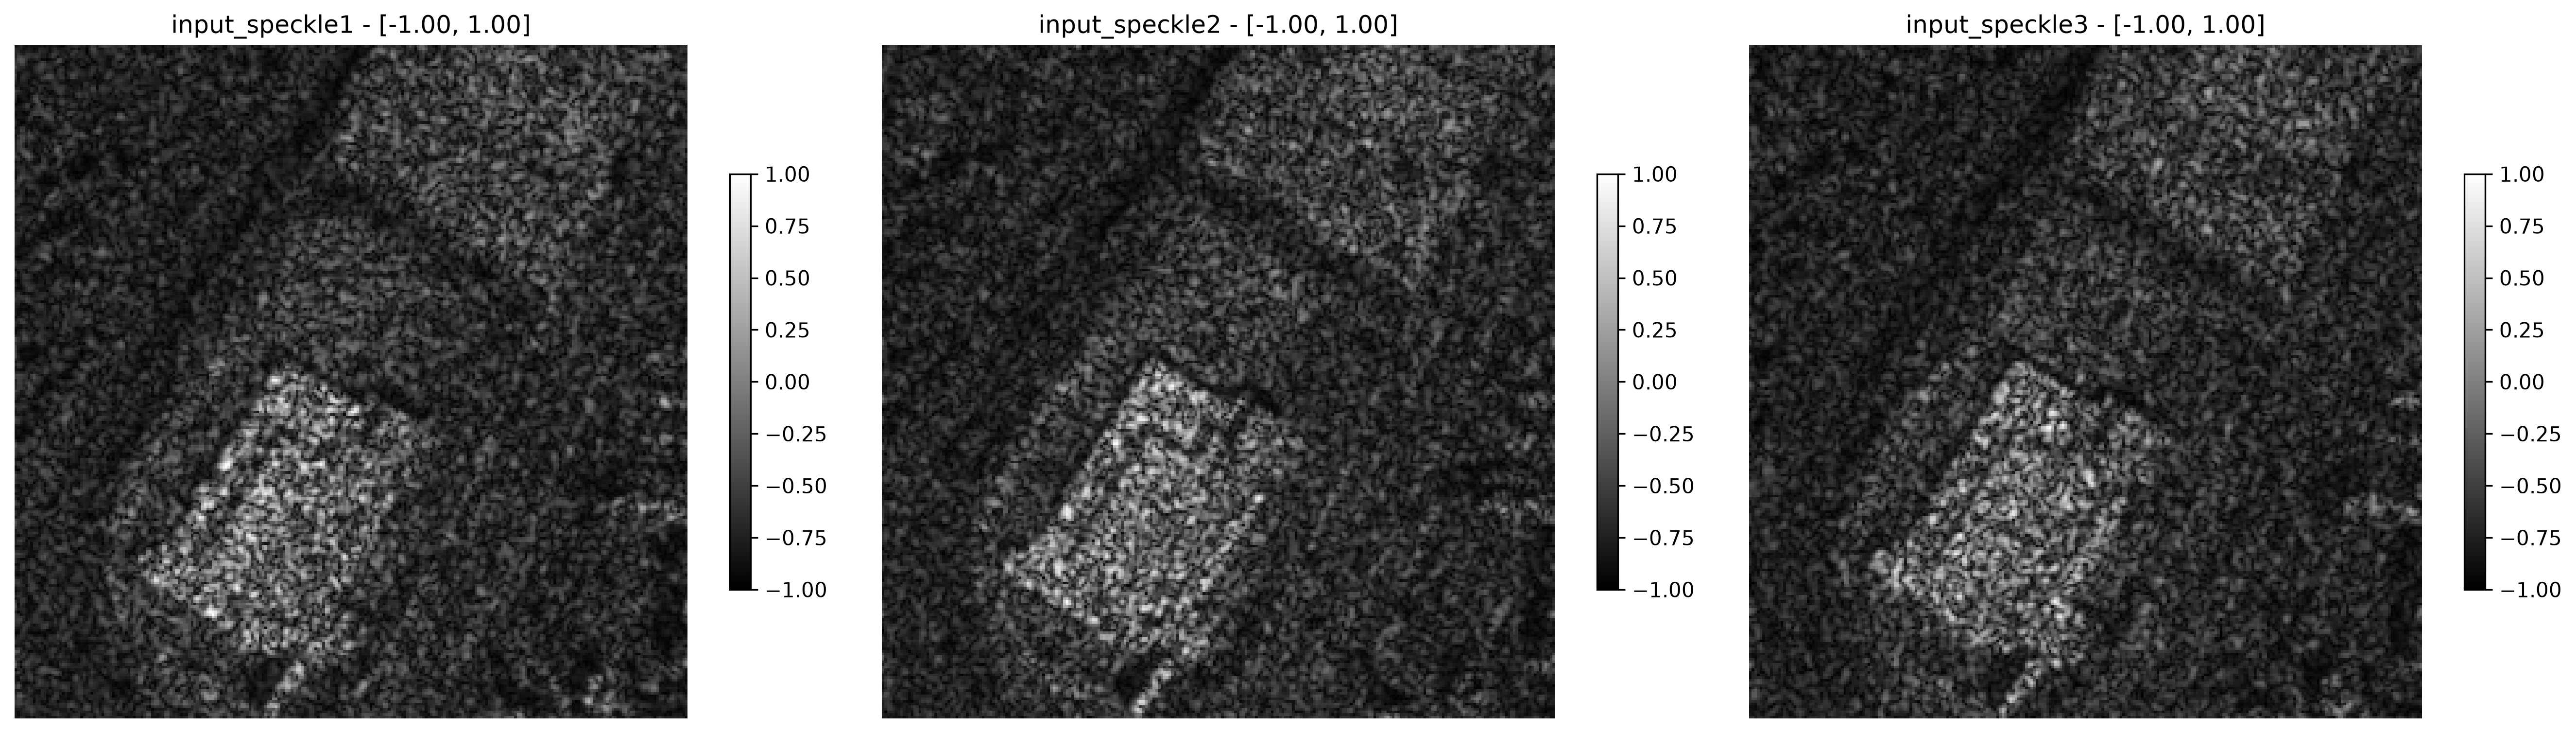

In [7]:
def to_11(x:torch.Tensor):
    return 2.0*x - 1.0

speckle1 = to_11(speckle1)
speckle2 = to_11(speckle2)
speckle3 = to_11(speckle3)


_plot(plots=[speckle1, speckle2, speckle3], 
      titles=[f'input_speckle1 - [{speckle1.min().item():0.2f}, {speckle1.max().item():0.2f}]',
              f'input_speckle2 - [{speckle2.min().item():0.2f}, {speckle2.max().item():0.2f}]',
              f'input_speckle3 - [{speckle3.min().item():0.2f}, {speckle3.max().item():0.2f}]'])